# Stability check: 5 repeated runs (vanilla, p1_classic, p2_classic)

`synthetic_compare.ipynb` ran every configuration once. This notebook repeats the three non-bound variants, `vanilla`, `p1_classic`, `p2_classic`, 5 times on each DLCC synthetic test case tc01–tc12 (excluding tc04) and reports the mean ± std of the final LogReg test accuracy, so we can see whether the single-run numbers are stable.

An earlier version of this notebook reused one fixed walk corpus (`walk_seed=42`) across all 5 runs and only varied the gensim seed, so it measured training variance but hid walk-sampling variance, which is a real source of run-to-run fluctuation in RDF2Vec. To measure the fluctuation fairly, each repetition now regenerates its own random-walk corpus with a different walk seed.

Sources of run-to-run variance exercised here:
- the random-walk corpus (instance walks and the protograph pretrain walks) is regenerated for every run with a different walk-generation seed, so walk-sampling variance is now included;
- the gensim model seed (random init for `vanilla`, pretrain init for the protograph variants) is varied across the 5 runs;
- gensim trains with 16 workers, so even a fixed seed is non-deterministic, and repeated runs surface that too.

For run *i* we set both the walk-generation seed and the gensim seed to `SEEDS[i]`, so each repetition is an independent end-to-end sample (walks, init, training). Walks are cached per `(tc, seed)` under `notebooks/5_times_varywalks/walks/<tc>/seed<seed>/`; delete that directory to regenerate. The work still lives in `scripts/_synthetic_compare.py`.

In [1]:
"""Setup: paths, shared configuration, the 11 test cases and 5 seeds."""
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
SCRIPTS = ROOT / "scripts"
OUT_ROOT = ROOT / "notebooks" / "5_times_varywalks"
WALK_ROOT = OUT_ROOT / "walks"   # walks regenerated per (tc, seed) — NOT shared with synthetic_compare
OUT_ROOT.mkdir(parents=True, exist_ok=True)

if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

from _synthetic_compare import (  # noqa: E402
    ensure_walks,
    run_protograph_variant,
    run_vanilla,
    write_protographs,
)

# tc01-tc12 excluding tc04
TCS = ["tc01", "tc02", "tc03", "tc05", "tc06", "tc07", "tc08", "tc09", "tc10", "tc11", "tc12"]
SEEDS = [42, 43, 44, 45, 46]
VARIANTS = ["vanilla", "p1_classic", "p2_classic"]

# Hyperparameters aligned with the MASCHInE training config
# (init_strategy=most_specific, init_relations=on, lr=0.025, no target-norm rescaling).
# NOTE: the walk-generation seed is no longer fixed here — for run i it equals SEEDS[i]
# (see ensure_tc_walks / run-all), so every repetition resamples its own walk corpus.
CFG = dict(
    dim=200,
    walks_per_entity=100,    # instance walks
    proto_walks_per_entity=200,
    depth=3,
    epochs=5,
    pretrain_epochs=5,
    vanilla_alpha=0.025,     # from-scratch LR (gensim default recipe)
    finetune_alpha=0.025,    # finetune LR for protograph variants (matches MASCHInE config lr)
    min_alpha=0.0001,
    target_norm=8.0,         # unused now (normalize=False); kept for reference
)


def tc_paths(tc: str) -> dict:
    tc_dir = ROOT / "v1" / "synthetic_ontology" / tc / "synthetic_ontology"
    return dict(
        ontology=tc_dir / "ontology.nt",
        graph=tc_dir / "graph.nt",
        train=tc_dir / "1000" / "train_test" / "train.txt",
        test=tc_dir / "1000" / "train_test" / "test.txt",
        walks=WALK_ROOT / tc,   # base dir; per-seed corpora live under <tc>/seed<seed>/
    )


for tc in TCS:
    for k, p in tc_paths(tc).items():
        if k != "walks":
            assert p.is_file(), f"Missing {k} for {tc}: {p}"

print(f"Output root: {OUT_ROOT}")
print(f"Walk cache:  {WALK_ROOT}  (regenerated per (tc, seed))")
print(f"Test cases ({len(TCS)}): {', '.join(TCS)}")
print(f"Seeds ({len(SEEDS)}): {SEEDS}  (drive BOTH walk generation and gensim training)")
print(f"Variants: {', '.join(VARIANTS)}")

Output root: /home/bnukhkadiev/Knowledge-Graphs/notebooks/5_times_varywalks
Walk cache:  /home/bnukhkadiev/Knowledge-Graphs/notebooks/5_times_varywalks/walks  (regenerated per (tc, seed))
Test cases (11): tc01, tc02, tc03, tc05, tc06, tc07, tc08, tc09, tc10, tc11, tc12
Seeds (5): [42, 43, 44, 45, 46]  (drive BOTH walk generation and gensim training)
Variants: vanilla, p1_classic, p2_classic


## Pipeline

Per test case, for each of the 5 seeds we first (re)generate that run's walk corpora, instance walks plus the P1/P2 protograph pretrain walks, with the run seed as the walk-generation seed (cached on disk under `<tc>/seed<seed>/`), then train `vanilla`, `p1_classic` and `p2_classic` with the same seed and record the per-epoch LogReg test-accuracy curve. Because the walks are resampled per run, the reported spread reflects walk-sampling variance as well as training randomness. Results are cached to `notebooks/5_times_varywalks/results.json`; delete it to re-run.

In [2]:
RESULTS_JSON = OUT_ROOT / "results.json"


def ensure_tc_walks(tc: str, seed: int) -> dict:
    """Protographs + cached walks (instance, p1, p2) for one run.

    The walk-generation seed equals the run seed, so each repetition resamples an
    independent walk corpus. Corpora are cached under <tc>/seed<seed>/ — delete
    that directory to regenerate.
    """
    p = tc_paths(tc)
    wout = p["walks"] / f"seed{seed}"
    wout.mkdir(parents=True, exist_ok=True)
    proto_paths = write_protographs(p["ontology"], wout)
    proto_walks = {
        kind: ensure_walks(
            proto_paths[kind],
            wout / f"walks_{kind}.txt",
            walks_per_entity=CFG["proto_walks_per_entity"],
            depth=CFG["depth"],
            seed=seed,
            ensure_triple_coverage=True,
        )
        for kind in ("p1", "p2")
    }
    inst_walks = ensure_walks(
        p["graph"],
        wout / f"walks_instance_w{CFG['walks_per_entity']}_d{CFG['depth']}.txt",
        walks_per_entity=CFG["walks_per_entity"],
        depth=CFG["depth"],
        seed=seed,
    )
    return dict(inst=inst_walks, p1=proto_walks["p1"], p2=proto_walks["p2"])


def run_tc_seed(tc: str, seed: int, walks: dict, *, t0: float, verbose: bool = True) -> list[dict]:
    """One repetition: vanilla + p1_classic + p2_classic at the given seed."""
    p = tc_paths(tc)
    shared = dict(dim=CFG["dim"], epochs=CFG["epochs"], min_alpha=CFG["min_alpha"], seed=seed)
    rows = []

    def record(res):
        res.pop("model", None)
        res["tc"] = tc
        res["seed"] = seed
        rows.append(res)
        if verbose:
            accs = " ".join(f"{a:.3f}" for a in res["accs"])
            print(f"  [{time.time()-t0:6.1f}s] seed={seed} {res['variant']:>11}  [{accs}]", flush=True)

    record(run_vanilla(
        walks["inst"], p["train"], p["test"], alpha=CFG["vanilla_alpha"], **shared,
    ))

    # MASCHInE-aligned init: most_specific strategy, relations initialized (mode="both"
    # default), vectors copied as-is (normalize=False), finetune at lr=0.025.
    proto_shared = dict(
        strategy="most_specific",
        normalize=False,
        target_norm=None,
        finetune_alpha=CFG["finetune_alpha"],
        pretrain_epochs=CFG["pretrain_epochs"],
        **shared,
    )
    for kind in ("p1", "p2"):
        record(run_protograph_variant(
            f"{kind}_classic", walks[kind], walks["inst"], p["ontology"],
            p["train"], p["test"], **proto_shared,
        ))
    return rows


def load_results() -> dict[str, list[dict]]:
    if RESULTS_JSON.is_file():
        return json.loads(RESULTS_JSON.read_text(encoding="utf-8"))
    return {}


def save_results(results: dict[str, list[dict]]) -> None:
    RESULTS_JSON.write_text(json.dumps(results, indent=2) + "\n", encoding="utf-8")


print("Pipeline ready.")

Pipeline ready.


In [3]:
"""Run all test cases x 5 seeds (cached per TC in results.json; delete it to re-run).
Each (tc, seed) regenerates its own walk corpus before training, so the spread includes
walk-sampling variance as well as training randomness."""
results = load_results()

for tc in TCS:
    expected = len(SEEDS) * len(VARIANTS)
    if len(results.get(tc, [])) == expected:
        print(f"{tc}: cached ({len(results[tc])} rows = {len(SEEDS)} seeds x {len(VARIANTS)} variants)")
        continue
    print(f"{tc}:")
    t0 = time.time()
    rows = []
    for seed in SEEDS:
        walks = ensure_tc_walks(tc, seed)   # fresh walk corpus per run
        rows.extend(run_tc_seed(tc, seed, walks, t0=t0))
    results[tc] = rows
    save_results(results)

print("\nDone.")

tc01:


jRDF2Vec duplicate-free [8 threads]:   0%|          | 0/421 [00:00<?, ?entity/s]

Triple coverage: appended 95 depth-1 walks for triples dropped by per-entity trimming.


jRDF2Vec duplicate-free [8 threads]:   0%|          | 0/649 [00:01<?, ?entity/s]

Triple coverage: appended 148 depth-1 walks for triples dropped by per-entity trimming.


...

jRDF2Vec duplicate-free [8 threads]:   0%|          | 0/14967 [00:00<?, ?entity/s]

  [ 810.0s] seed=46     vanilla  [0.482 0.647 0.660 0.675 0.662 0.655]


  [ 872.0s] seed=46  p1_classic  [0.482 0.667 0.677 0.695 0.680 0.675]


  [ 939.2s] seed=46  p2_classic  [0.482 0.695 0.682 0.703 0.688 0.698]



Done.


## Stability of the final accuracy

Mean ± std of the epoch-5 LogReg test accuracy across the 5 runs, per test case and variant. A small std means the single-run number in `synthetic_compare.ipynb` is trustworthy.

In [4]:
def long_frame(results: dict) -> pd.DataFrame:
    recs = []
    for tc in TCS:
        for r in results.get(tc, []):
            recs.append(dict(
                tc=tc, variant=r["variant"], seed=r["seed"],
                init_acc=r["accs"][0], final_acc=r["final_acc"], best_acc=max(r["accs"]),
            ))
    return pd.DataFrame(recs)


df = long_frame(results)

agg = (
    df.groupby(["tc", "variant"])["final_acc"]
    .agg(mean="mean", std="std", min="min", max="max")
    .reset_index()
)

# mean +/- std formatted, one column per variant
agg["cell"] = agg.apply(lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1)
table = agg.pivot(index="tc", columns="variant", values="cell")[VARIANTS].reindex(TCS)
print("Final LogReg test accuracy (epoch 5) — mean ± std over 5 runs")
display(table)

mean_tbl = agg.pivot(index="tc", columns="variant", values="mean")[VARIANTS].reindex(TCS)
std_tbl = agg.pivot(index="tc", columns="variant", values="std")[VARIANTS].reindex(TCS)
mean_tbl.loc["mean"] = mean_tbl.mean()
std_tbl.loc["max"] = std_tbl.max()
print("\nMean final accuracy")
display(mean_tbl.round(4))
print("\nStd of final accuracy (last row = worst-case std per variant)")
display(std_tbl.round(4))

Final LogReg test accuracy (epoch 5) — mean ± std over 5 runs


variant,vanilla,p1_classic,p2_classic
tc,,,
tc01,0.942 ± 0.006,0.948 ± 0.008,0.947 ± 0.010
tc02,0.857 ± 0.018,0.859 ± 0.013,0.855 ± 0.007
tc03,0.935 ± 0.009,0.934 ± 0.011,0.932 ± 0.005
tc05,0.846 ± 0.005,0.839 ± 0.012,0.851 ± 0.019
tc06,0.985 ± 0.003,0.985 ± 0.002,0.987 ± 0.002
tc07,0.578 ± 0.016,0.564 ± 0.016,0.575 ± 0.011
tc08,0.613 ± 0.022,0.586 ± 0.008,0.594 ± 0.019
tc09,0.634 ± 0.009,0.639 ± 0.019,0.629 ± 0.009
tc10,0.663 ± 0.005,0.676 ± 0.008,0.674 ± 0.010



Mean final accuracy


variant,vanilla,p1_classic,p2_classic
tc,,,
tc01,0.9420,0.9475,0.9465
tc02,0.8570,0.8590,0.8555
tc03,0.9355,0.9335,0.9320
tc05,0.8455,0.8385,0.8510
tc06,0.9845,0.9850,0.9870
tc07,0.5780,0.5640,0.5745
tc08,0.6135,0.5855,0.5940
tc09,0.6345,0.6395,0.6290
tc10,0.6630,0.6760,0.6740



Std of final accuracy (last row = worst-case std per variant)


variant,vanilla,p1_classic,p2_classic
tc,,,
tc01,0.0060,0.0077,0.0098
tc02,0.0180,0.0131,0.0074
tc03,0.0087,0.0113,0.0048
tc05,0.0054,0.0118,0.0194
tc06,0.0033,0.0018,0.0021
tc07,0.0156,0.0158,0.0114
tc08,0.0218,0.0082,0.0185
tc09,0.0093,0.0192,0.0086
tc10,0.0048,0.0080,0.0099


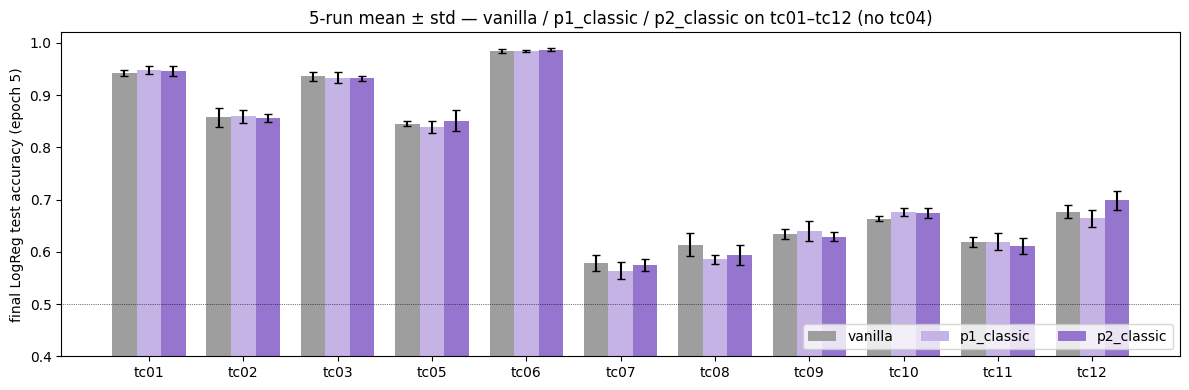

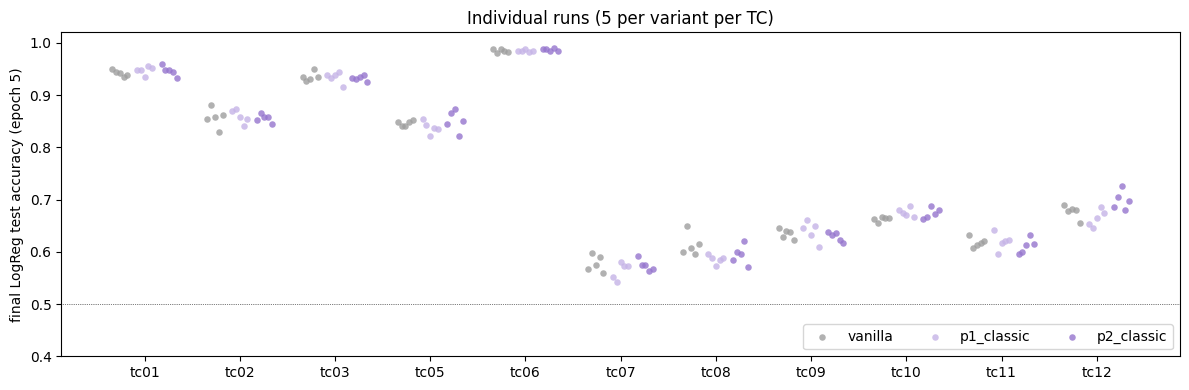

In [5]:
"""Per-TC final accuracy with std error bars across the 5 runs."""
import matplotlib.pyplot as plt

COLORS = {"vanilla": "#9e9e9e", "p1_classic": "#c5b3e6", "p2_classic": "#9575cd"}

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(TCS))
w = 0.26
for i, v in enumerate(VARIANTS):
    means = [agg[(agg.tc == tc) & (agg.variant == v)]["mean"].iloc[0] for tc in TCS]
    stds = [agg[(agg.tc == tc) & (agg.variant == v)]["std"].iloc[0] for tc in TCS]
    ax.bar(x + (i - 1) * w, means, w, yerr=stds, capsize=3, label=v, color=COLORS[v])
ax.set_xticks(x, TCS)
ax.set_ylim(0.4, 1.02)
ax.axhline(0.5, color="k", lw=0.5, ls=":")
ax.set_ylabel("final LogReg test accuracy (epoch 5)")
ax.set_title("5-run mean ± std — vanilla / p1_classic / p2_classic on tc01–tc12 (no tc04)")
ax.legend(ncol=3, loc="lower right")
fig.tight_layout()
fig.savefig(OUT_ROOT / "final_accuracy_mean_std.png", dpi=150)
plt.show()

# strip plot: each individual run as a dot, to eyeball the spread
fig, ax = plt.subplots(figsize=(12, 4))
for i, v in enumerate(VARIANTS):
    sub = df[df.variant == v]
    for j, tc in enumerate(TCS):
        vals = sub[sub.tc == tc]["final_acc"].to_numpy()
        jitter = (np.arange(len(vals)) - (len(vals) - 1) / 2) * 0.04
        ax.scatter(np.full(len(vals), j + (i - 1) * w) + jitter, vals,
                   s=22, color=COLORS[v], alpha=0.8, lw=0,
                   label=v if j == 0 else None)
ax.set_xticks(x, TCS)
ax.set_ylim(0.4, 1.02)
ax.axhline(0.5, color="k", lw=0.5, ls=":")
ax.set_ylabel("final LogReg test accuracy (epoch 5)")
ax.set_title("Individual runs (5 per variant per TC)")
ax.legend(ncol=3, loc="lower right")
fig.tight_layout()
fig.savefig(OUT_ROOT / "final_accuracy_individual_runs.png", dpi=150)
plt.show()

In [6]:
"""Overall stability summary."""
print("Std of final accuracy across 5 runs, summarized over the 11 test cases:\n")
for v in VARIANTS:
    s = agg[agg.variant == v]["std"]
    print(f"  {v:>11}:  mean std = {s.mean():.4f}   max std = {s.max():.4f}   "
          f"(worst TC: {agg.loc[s.idxmax(), 'tc']})")

print("\nAcross every (tc, variant) cell:")
print(f"  overall mean std = {agg['std'].mean():.4f}")
print(f"  overall max  std = {agg['std'].max():.4f}")

Std of final accuracy across 5 runs, summarized over the 11 test cases:

      vanilla:  mean std = 0.0105   max std = 0.0218   (worst TC: tc08)
   p1_classic:  mean std = 0.0118   max std = 0.0192   (worst TC: tc09)
   p2_classic:  mean std = 0.0113   max std = 0.0194   (worst TC: tc05)

Across every (tc, variant) cell:
  overall mean std = 0.0112
  overall max  std = 0.0218


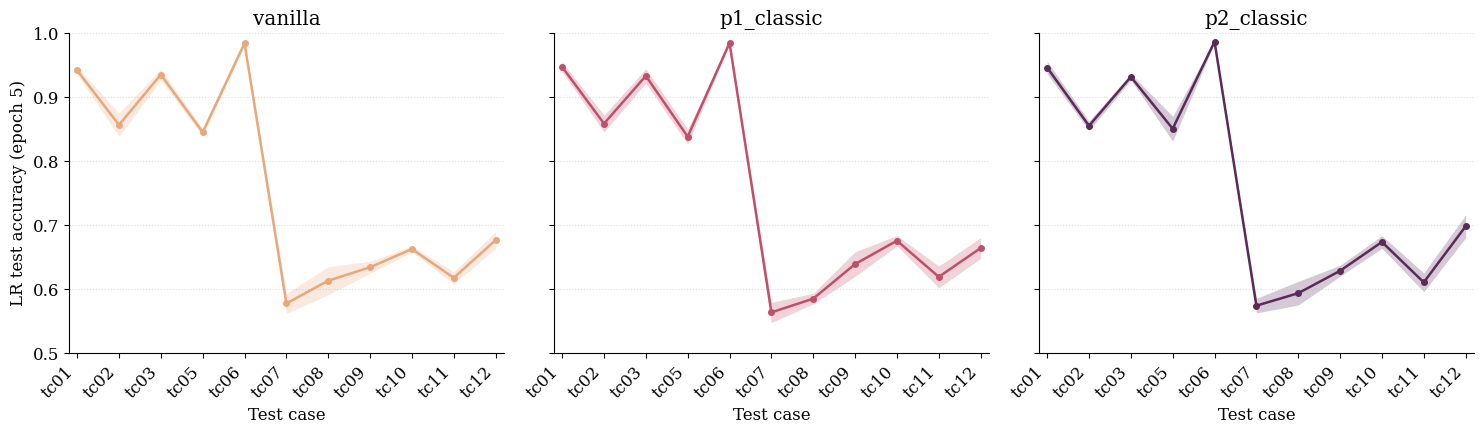

In [7]:
"""Ribbon plot: per-TC mean final accuracy with a +/-1 std band, one panel per variant.
The band also covers walk-sampling variance, since every run resamples its own walk corpus.
Reads notebooks/5_times_varywalks/results.json directly, so it runs on a fresh kernel.
"""
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUT_ROOT = Path("..").resolve() / "notebooks" / "5_times_varywalks"
TCS = ["tc01", "tc02", "tc03", "tc05", "tc06", "tc07", "tc08", "tc09", "tc10", "tc11", "tc12"]
VARIANTS = ["vanilla", "p1_classic", "p2_classic"]
RIBBON_COLORS = {"vanilla": "#e8a87c", "p1_classic": "#c0506a", "p2_classic": "#5a2a5a"}

results = json.loads((OUT_ROOT / "results.json").read_text(encoding="utf-8"))
df = pd.DataFrame([
    dict(tc=tc, variant=r["variant"], final_acc=r["final_acc"])
    for tc in TCS for r in results.get(tc, [])
])
agg = df.groupby(["tc", "variant"])["final_acc"].agg(mean="mean", std="std").reset_index()

with plt.rc_context({"font.family": "serif", "font.size": 12,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "mathtext.fontset": "cm"}):
    x = np.arange(len(TCS))
    fig, axes = plt.subplots(1, len(VARIANTS), figsize=(15, 4.5), sharey=True)
    for ax, v in zip(axes, VARIANTS):
        means = np.array([agg[(agg.tc == tc) & (agg.variant == v)]["mean"].iloc[0] for tc in TCS])
        stds = np.array([agg[(agg.tc == tc) & (agg.variant == v)]["std"].iloc[0] for tc in TCS])
        c = RIBBON_COLORS[v]
        ax.fill_between(x, means - stds, means + stds, color=c, alpha=0.25, lw=0)
        ax.plot(x, means, color=c, marker="o", ms=4, lw=1.8)
        ax.set_title(v)
        ax.set_xticks(x, TCS, rotation=45, ha="right")
        ax.set_xlabel("Test case")
        ax.margins(x=0.02)
        ax.grid(axis="y", ls=":", alpha=0.4)
    axes[0].set_ylabel("LR test accuracy (epoch 5)")
    axes[0].set_ylim(0.5, 1.0)
    fig.tight_layout()
    fig.savefig(OUT_ROOT / "stability_ribbon.png", dpi=200, bbox_inches="tight")
    plt.show()